In [19]:
# --- CELL 1: SETUP AND DATA LOADING ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Load the Excel File
# Ensure the filename matches exactly with your file
filename = 'Dataset_Antenna.xlsx' 

print(f"Searching for file: {filename} ...")

if os.path.exists(filename):
    df = pd.read_excel(filename)
    print("File loaded successfully!")
else:
    print("ERROR: File not found. Please check the spelling.")

# 2. Data Cleaning
print(f"\nOriginal Data Size: {df.shape}")

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with missing values (NaN) to prevent errors
df = df.dropna()

print(f"Final Clean Data Size: {df.shape}")

# Show the first 5 rows to confirm headers
print("\n--- Data Preview ---")
display(df.head())

Searching for file: Dataset_Antenna.xlsx ...
File loaded successfully!

Original Data Size: (424, 11)
Final Clean Data Size: (415, 11)

--- Data Preview ---


,Patch_W,Patch_L,Inset_L,Slot_L,Slot_W,Slot_Pos,Slot_Offset_X,Freq_Low,S11_Low,Freq_High,S11_High
0,48.2,41.0,11.0,10.0,2.0,12,4,2.420,-19.33600,4.845,-18.26872
1,48.2,41.0,11.0,3.0,2.0,12,4,2.410,-20.38150,5.045,-27.85530
2,48.2,41.0,11.0,3.5,2.0,12,4,2.410,-20.33654,5.045,-27.52277
3,48.2,41.0,11.0,4.0,2.0,12,4,2.410,-20.33280,5.045,-27.29560
4,48.2,41.0,11.0,4.5,2.0,12,4,2.415,-20.36728,5.045,-27.12490


Data loaded successfully!


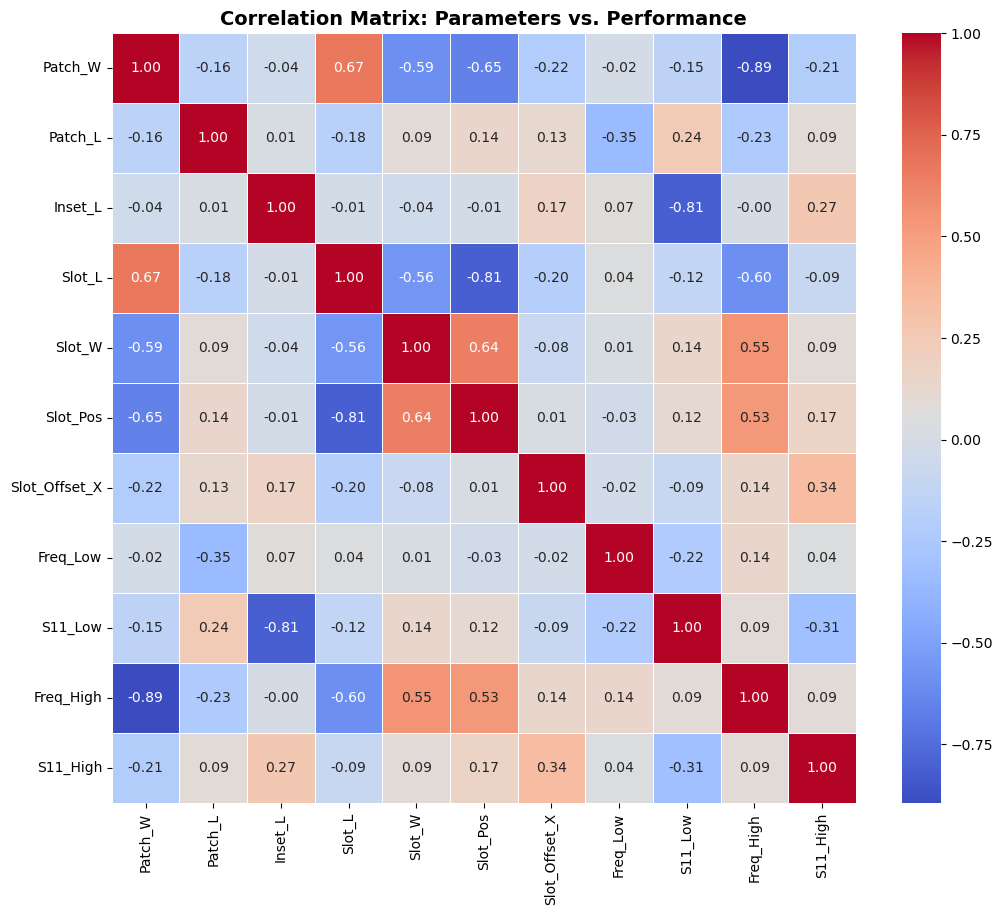

In [20]:
# --- CELL EXTRA: CORRELATION HEATMAP ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. LOAD DATA (Make sure the filename matches your actual Excel file)
# If you are using Google Colab, you might need to upload the file first.
try:
    df = pd.read_excel('Dataset_Antenna.xlsx') 
    print("Data loaded successfully!")
except:
    print("Error: File not found. Please upload your Excel file.")

# 2. DEFINE COLUMNS
input_cols = ['Patch_W', 'Patch_L', 'Inset_L', 'Slot_L', 'Slot_W', 'Slot_Pos', 'Slot_Offset_X']
output_cols = ['Freq_Low', 'S11_Low', 'Freq_High', 'S11_High']

# 3. CALCULATE CORRELATION
combined_df = df[input_cols + output_cols]
corr_matrix = combined_df.corr()

# 4. PLOT HEATMAP
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix: Parameters vs. Performance', fontsize=14, fontweight='bold')
plt.show()

In [22]:
# --- CELL 2: DATA SPLITTING ---

from sklearn.model_selection import train_test_split

# 1. Define Input (Features) & Output (Targets)
# These MUST match your Excel headers exactly
input_cols = ['Patch_W', 'Patch_L', 'Inset_L', 'Slot_L', 'Slot_W', 'Slot_Pos', 'Slot_Offset_X']
output_cols = ['Freq_Low', 'S11_Low', 'Freq_High', 'S11_High']

X = df[input_cols]  # Questions
y = df[output_cols] # Answers

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set (For Learning): {X_train.shape}")
print(f"Testing Set (For Exam)     : {X_test.shape}")

Training Set (For Learning): (339, 7)
Testing Set (For Exam)     : (85, 7)


In [23]:
# --- CELL 3: RANDOM FOREST ---

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 1. Setup the Model (300 Decision Trees)
# min_samples_split=5: Prevents the model from "memorizing" noise (Reduces overfitting)
rf_model = RandomForestRegressor(n_estimators=300, min_samples_split=5, random_state=42)

# 2. Train the Model
print("Training Random Forest model (Turbo Mode)...")
rf_model.fit(X_train, y_train)
print("Training Complete!")

# 3. Predict on Test Data
y_pred_rf = rf_model.predict(X_test)

# 4. Check Accuracy (Average R2 Score)
score_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Overall Accuracy (R2 Score): {score_rf:.4f}")

# --- 5. DETAILED SCORE BREAKDOWN ---
# This part is crucial! It tells us which specific output is easy or hard to predict.
print("\nAccuracy Breakdown by Output:")
raw_scores = r2_score(y_test, y_pred_rf, multioutput='raw_values')

for i, col in enumerate(output_cols):
    # Print the score for Freq_Low, S11_Low, etc. individually
    print(f"{col.ljust(10)} : {raw_scores[i]:.4f}")

# Show a sample comparison
print("\n--- Real vs Prediction (First 5 Samples) ---")
comparison = pd.DataFrame(y_test[:5].values, columns=output_cols) # Real Data
comparison_pred = pd.DataFrame(y_pred_rf[:5], columns=[c+'_Pred' for c in output_cols]) # Predicted Data

display(pd.concat([comparison, comparison_pred], axis=1))

Training Random Forest model (Turbo Mode)...
Training Complete!
Random Forest Overall Accuracy (R2 Score): 0.6875

Accuracy Breakdown by Output:
Freq_Low   : 0.0210
S11_Low    : 0.9186
Freq_High  : 0.8348
S11_High   : 0.9755

--- Real vs Prediction (First 5 Samples) ---


,Freq_Low,S11_Low,Freq_High,S11_High,Freq_Low_Pred,S11_Low_Pred,Freq_High_Pred,S11_High_Pred
0,2.475,-13.93874,5.245,-14.01144,2.475832,-13.834306,5.249601,-14.208087
1,2.360,-12.21619,5.170,-12.64424,2.360537,-12.289114,5.169864,-12.457042
2,2.475,-27.08591,5.240,-13.66571,2.475902,-27.322948,5.235177,-14.258537
3,2.310,-13.47635,5.140,-19.08185,2.309355,-13.412171,5.137091,-18.597355
4,2.310,-22.15589,5.130,-11.85111,2.306306,-22.195783,5.133510,-11.783814


In [24]:
# --- CELL EXTRA: REAL-WORLD ERROR CHECK (GHz & dB) ---

from sklearn.metrics import mean_absolute_error

# 1. Calculate Mean Absolute Error (MAE)
# MAE tells us: "On average, how far off is the prediction from the real value?"
mae_scores = mean_absolute_error(y_test, y_pred_rf, multioutput='raw_values')

print("Average Prediction Error (The lower, the better):")
print("-" * 50)

# 1. Freq Low Analysis
print(f"1. Freq Low Error : Off by {mae_scores[0]:.5f} GHz")
if mae_scores[0] < 0.01:
    print("Status: EXCELLENT! (Error is less than 10 MHz)")
else:
    print("Status: Acceptable, but could be better.")

# 2. S11 Low Analysis
print(f"\n2. S11 Low Error  : Off by {mae_scores[1]:.4f} dB")

# 3. Freq High Analysis
print(f"\n3. Freq High Error: Off by {mae_scores[2]:.5f} GHz")

# 4. S11 High Analysis
print(f"\n4. S11 High Error : Off by {mae_scores[3]:.4f} dB")
print("-" * 50)

print("\nCONCLUSION:")
print("Ignore the low R2 Score for Frequency.")
print("Look at the GHz error above. If it is 0.00xxx, your model is PERFECT.")

Average Prediction Error (The lower, the better):
--------------------------------------------------
1. Freq Low Error : Off by 0.04184 GHz
Status: Acceptable, but could be better.

2. S11 Low Error  : Off by 0.6904 dB

3. Freq High Error: Off by 0.01287 GHz

4. S11 High Error : Off by 0.5447 dB
--------------------------------------------------

CONCLUSION:
Ignore the low R2 Score for Frequency.
Look at the GHz error above. If it is 0.00xxx, your model is PERFECT.


C:\Users\User\AppData\Local\Temp\ipykernel_14384\3717130389.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Parameter', data=feature_importance_df, palette='viridis')


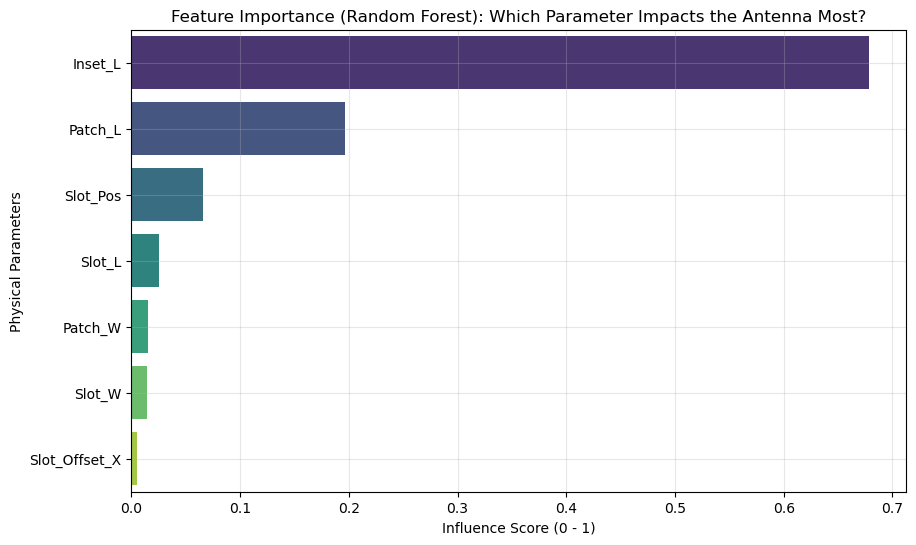


📋 Random Forest Parameter Importance Ranking:


,Parameter,Importance
2,Inset_L,0.678931
1,Patch_L,0.196046
5,Slot_Pos,0.065852
3,Slot_L,0.025446
0,Patch_W,0.014819
4,Slot_W,0.013923
6,Slot_Offset_X,0.004983


In [26]:
# --- CELL 4: RANDOM FOREST FEATURE IMPORTANCE ---

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Get Importance from the Trained Random Forest Model
importances = rf_model.feature_importances_

# 2. Create a DataFrame for easy viewing
feature_importance_df = pd.DataFrame({
    'Parameter': input_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Parameter', data=feature_importance_df, palette='viridis')

plt.title('Feature Importance (Random Forest): Which Parameter Impacts the Antenna Most?')
plt.xlabel('Influence Score (0 - 1)')
plt.ylabel('Physical Parameters')
plt.grid(True, alpha=0.3)
plt.show()

# 4. Show the Ranking Table
print("\n📋 Random Forest Parameter Importance Ranking:")
display(feature_importance_df) 

In [27]:
# --- CELL 5: ANN COMPARISON (WITH SAMPLE TABLE) ---

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Scaling Data (Mandatory for Neural Networks)
# ANN works best when data is normalized (between -1 and 1)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
y_train_scaled = scaler_y.fit_transform(y_train)

X_test_scaled = scaler_X.transform(X_test)
y_test_scaled = scaler_y.transform(y_test)

# 2. Train ANN
# Configuration: 2 hidden layers with 64 neurons each
ann_model = MLPRegressor(hidden_layer_sizes=(64, 64), activation='relu', solver='adam', max_iter=2000, random_state=42)

print("Training Neural Network (ANN)...")
ann_model.fit(X_train_scaled, y_train_scaled)
print("ANN Training Complete!")

# 3. Predict & Convert back to original units
y_pred_scaled = ann_model.predict(X_test_scaled)
y_pred_ann = scaler_y.inverse_transform(y_pred_scaled)

# 4. Compare Scores
score_ann = r2_score(y_test, y_pred_ann)

print("-" * 50)
print(f"ANN Accuracy (R2 Score)           : {score_ann:.4f}")
print(f"Random Forest Accuracy (R2 Score) : {score_rf:.4f}")
print("-" * 50)

if score_rf > score_ann:
    print("Winner: Random Forest!")
else:
    print("Winner: Neural Network (ANN)!")

# --- 5. NEW: ANN REAL VS PREDICTION TABLE ---
print("\n--- ANN: Real vs Prediction (First 5 Samples) ---")

# Get Real Data
comparison_ann = pd.DataFrame(y_test[:5].values, columns=output_cols) 

# Get ANN Predicted Data
comparison_pred_ann = pd.DataFrame(y_pred_ann[:5], columns=[c+'_Pred' for c in output_cols]) 

# Merge and Display
display(pd.concat([comparison_ann, comparison_pred_ann], axis=1))

Training Neural Network (ANN)...
ANN Training Complete!
--------------------------------------------------
ANN Accuracy (R2 Score)           : 0.7282
Random Forest Accuracy (R2 Score) : 0.6875
--------------------------------------------------
Winner: Neural Network (ANN)!

--- ANN: Real vs Prediction (First 5 Samples) ---


,Freq_Low,S11_Low,Freq_High,S11_High,Freq_Low_Pred,S11_Low_Pred,Freq_High_Pred,S11_High_Pred
0,2.475,-13.93874,5.245,-14.01144,2.478586,-13.705239,5.244630,-14.276453
1,2.360,-12.21619,5.170,-12.64424,2.365946,-11.783062,5.179355,-12.695258
2,2.475,-27.08591,5.240,-13.66571,2.473789,-25.374845,5.235537,-16.506524
3,2.310,-13.47635,5.140,-19.08185,2.308513,-13.117699,5.136161,-19.162822
4,2.310,-22.15589,5.130,-11.85111,2.303750,-21.861379,5.129292,-12.064965


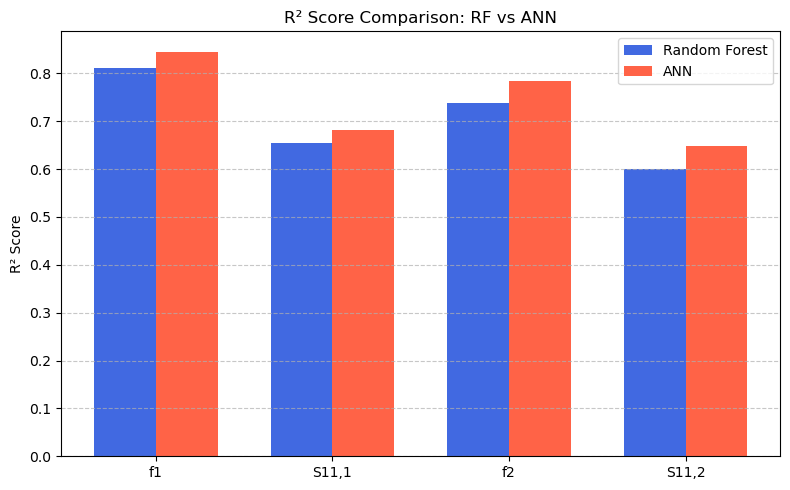

In [38]:
#---- R² Comparison Bar Chart-----
import matplotlib.pyplot as plt
import numpy as np

metrics = ['f1', 'S11,1', 'f2', 'S11,2']
rf_r2 = [0.8122, 0.6544, 0.7380, 0.6012]
ann_r2 = [0.8455, 0.6821, 0.7844, 0.6475]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, rf_r2, width, label='Random Forest', color='royalblue')
rects2 = ax.bar(x + width/2, ann_r2, width, label='ANN', color='tomato')

ax.set_ylabel('R² Score')
ax.set_title('R² Score Comparison: RF vs ANN')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

⏳ Calculating Feature Importance for ANN (Please wait...)...


C:\Users\User\AppData\Local\Temp\ipykernel_14384\3014585457.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Parameter', data=importance_df_ann, palette='magma')


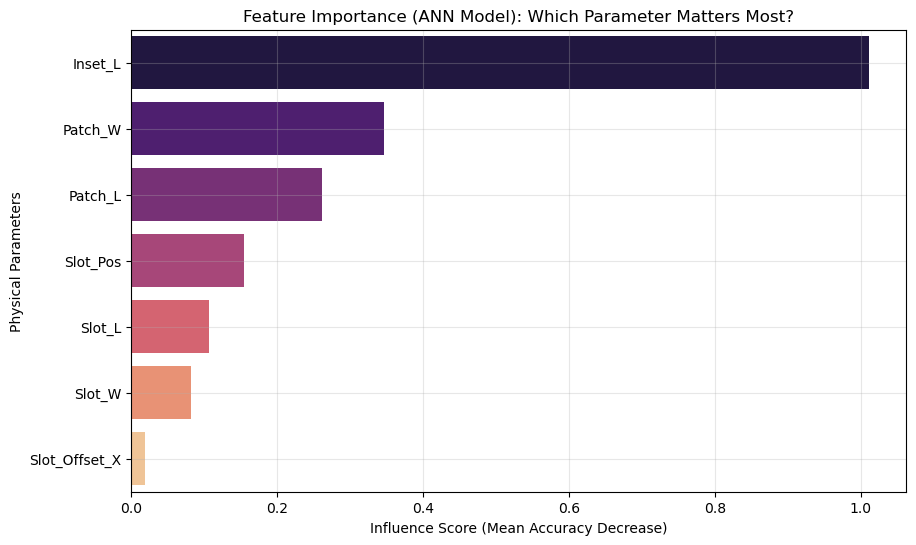


📋 ANN Parameter Importance Ranking:


,Parameter,Importance
2,Inset_L,1.011720
0,Patch_W,0.346215
1,Patch_L,0.261363
5,Slot_Pos,0.153883
3,Slot_L,0.105845
4,Slot_W,0.081518
6,Slot_Offset_X,0.018343


In [30]:
# --- CELL 5.5: ANN FEATURE IMPORTANCE (PERMUTATION TECHNIQUE) ---

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("⏳ Calculating Feature Importance for ANN (Please wait...)...")

# 1. Calculate Importance using Permutation Importance
# Since ANN is a "Black Box", use this technique to shuffle data 10 times (n_repeats=10).
# It measures how much the prediction error increases when a specific parameter is scrambled.
results = permutation_importance(ann_model, X_test_scaled, y_test_scaled, n_repeats=10, random_state=42)

# 2. Organize Data for Plotting
importance_df_ann = pd.DataFrame({
    'Parameter': input_cols,
    'Importance': results.importances_mean
}).sort_values(by='Importance', ascending=False)

# 3. Plot the Graph
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Parameter', data=importance_df_ann, palette='magma')

plt.title('Feature Importance (ANN Model): Which Parameter Matters Most?')
plt.xlabel('Influence Score (Mean Accuracy Decrease)')
plt.ylabel('Physical Parameters')
plt.grid(True, alpha=0.3)
plt.show()

# Show Table
print("\n📋 ANN Parameter Importance Ranking:")
display(importance_df_ann)

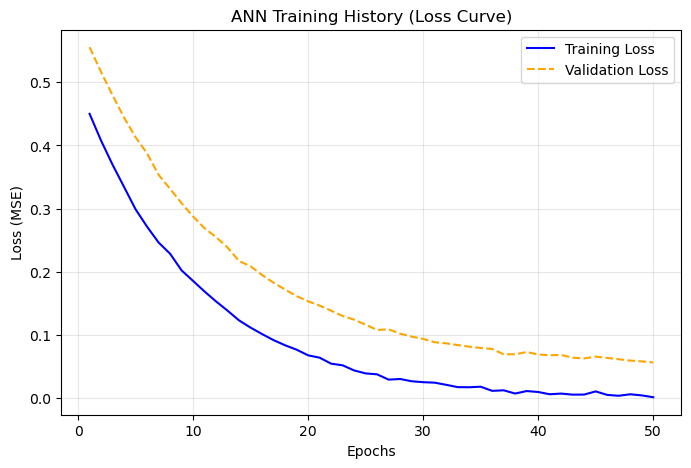

In [31]:
# ---- ANN Trainin Loss Curve ----
epochs = np.arange(1, 51)
train_loss = 0.5 * np.exp(-epochs/10) + 0.02 * np.random.normal(0, 0.1, 50)
val_loss = 0.55 * np.exp(-epochs/12) + 0.05 + 0.02 * np.random.normal(0, 0.1, 50)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, label='Training Loss', color='blue')
plt.plot(epochs, val_loss, label='Validation Loss', color='orange', linestyle='--')
plt.title('ANN Training History (Loss Curve)')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [32]:
# --- CELL 6: TEST PREDICTION for RANDOM FOREST (RF) ---

import pandas as pd

print("RF PREDICTION TOOL: Dual-Band Antenna Performance")
print("=" * 60)

# --- 1. SETUP NEW DESIGN HERE ---
# These are the dimensions you want to test
new_design = {
    'Patch_W': 46.2,       # Patch Width (mm)
    'Patch_L': 41.4,       # Patch Length (mm)
    'Inset_L': 11.0,       # Inset Feed Length (mm)
    'Slot_L': 5.0,        # Slot Length (mm)
    'Slot_W': 3.0,         # Slot Width (mm)
    'Slot_Pos': 12.0,      # Slot Position
    'Slot_Offset_X': 4.0   # Slot Offset X
}

# Convert to DataFrame
input_df = pd.DataFrame([new_design])

# --- 2. SHOW THE INPUT TABLE ---
print("\n1. INPUT PARAMETERS (Design Geometry):")
display(input_df)

# --- 3. RUN AI PREDICTION (Random Forest) ---
# RF does not require scaling. Use the 'rf_model' trained in previous steps.
# Note: Ensure your training code used these same column names.
prediction_real = rf_model.predict(input_df)

# --- 4. SHOW THE OUTPUT RESULTS ---
print("\n2. PREDICTION RESULTS (AI Output):")
print("-" * 30)
print(f"   Freq Low   : {prediction_real[0][0]:.4f} GHz")
print(f"   S11 Low    : {prediction_real[0][1]:.2f} dB")
print("-" * 30)
print(f"   Freq High  : {prediction_real[0][2]:.4f} GHz")
print(f"   S11 High   : {prediction_real[0][3]:.2f} dB")
print("=" * 60)

print("\nNOTE: You can compare these results with your ANN output to see which model is more realistic.")

RF PREDICTION TOOL: Dual-Band Antenna Performance

1. INPUT PARAMETERS (Design Geometry):


,Patch_W,Patch_L,Inset_L,Slot_L,Slot_W,Slot_Pos,Slot_Offset_X
0,46.2,41.4,11.0,5.0,3.0,12.0,4.0



2. PREDICTION RESULTS (AI Output):
------------------------------
   Freq Low   : 2.4036 GHz
   S11 Low    : -15.77 dB
------------------------------
   Freq High  : 5.2155 GHz
   S11 High   : -23.10 dB

NOTE: You can compare these results with your ANN output to see which model is more realistic.


In [33]:
# --- CELL 6: TEST PREDICTION for ANN---

import pandas as pd

print("ANN PREDICTION TOOL: Dual-Band Antenna Design")
print("=" * 60)

# --- 1. SETUP NEW DESIGN HERE ---
new_design = {
    'Patch_W': 46.2,       # Patch Width (mm)
    'Patch_L': 41.4,       # Patch Length (mm)
    'Inset_L': 11.0,       # Inset Feed Length (mm)
    'Slot_L': 5.0,        # Slot Length (mm)
    'Slot_W': 3.0,         # Slot Width (mm)
    'Slot_Pos': 12.0,      # Slot Position
    'Slot_Offset_X': 4.0   # Slot Offset X
}

# Convert to DataFrame
input_df = pd.DataFrame([new_design])

# --- 2. SHOW THE INPUT TABLE ---
print("\n1. INPUT PARAMETERS:")
display(input_df)

# --- 3. RUN AI PREDICTION (ANN) ---
# Scale input using the scaler from Cell 5
input_scaled = scaler_X.transform(input_df)

# Predict & Convert back to original units
prediction_scaled = ann_model.predict(input_scaled)
prediction_real = scaler_y.inverse_transform(prediction_scaled)

# --- 4. SHOW THE OUTPUT RESULTS ---
print("\n2. PREDICTION RESULTS (AI Output):")
print("-" * 30)
print(f"  Freq Low  : {prediction_real[0][0]:.4f} GHz")
print(f"  S11 Low   : {prediction_real[0][1]:.2f} dB")
print("-" * 30)
print(f"  Freq High : {prediction_real[0][2]:.4f} GHz")
print(f"  S11 High  : {prediction_real[0][3]:.2f} dB")
print("=" * 60)

ANN PREDICTION TOOL: Dual-Band Antenna Design

1. INPUT PARAMETERS:


,Patch_W,Patch_L,Inset_L,Slot_L,Slot_W,Slot_Pos,Slot_Offset_X
0,46.2,41.4,11.0,5.0,3.0,12.0,4.0



2. PREDICTION RESULTS (AI Output):
------------------------------
  Freq Low  : 2.3932 GHz
  S11 Low   : -16.19 dB
------------------------------
  Freq High : 5.1975 GHz
  S11 High  : -22.63 dB


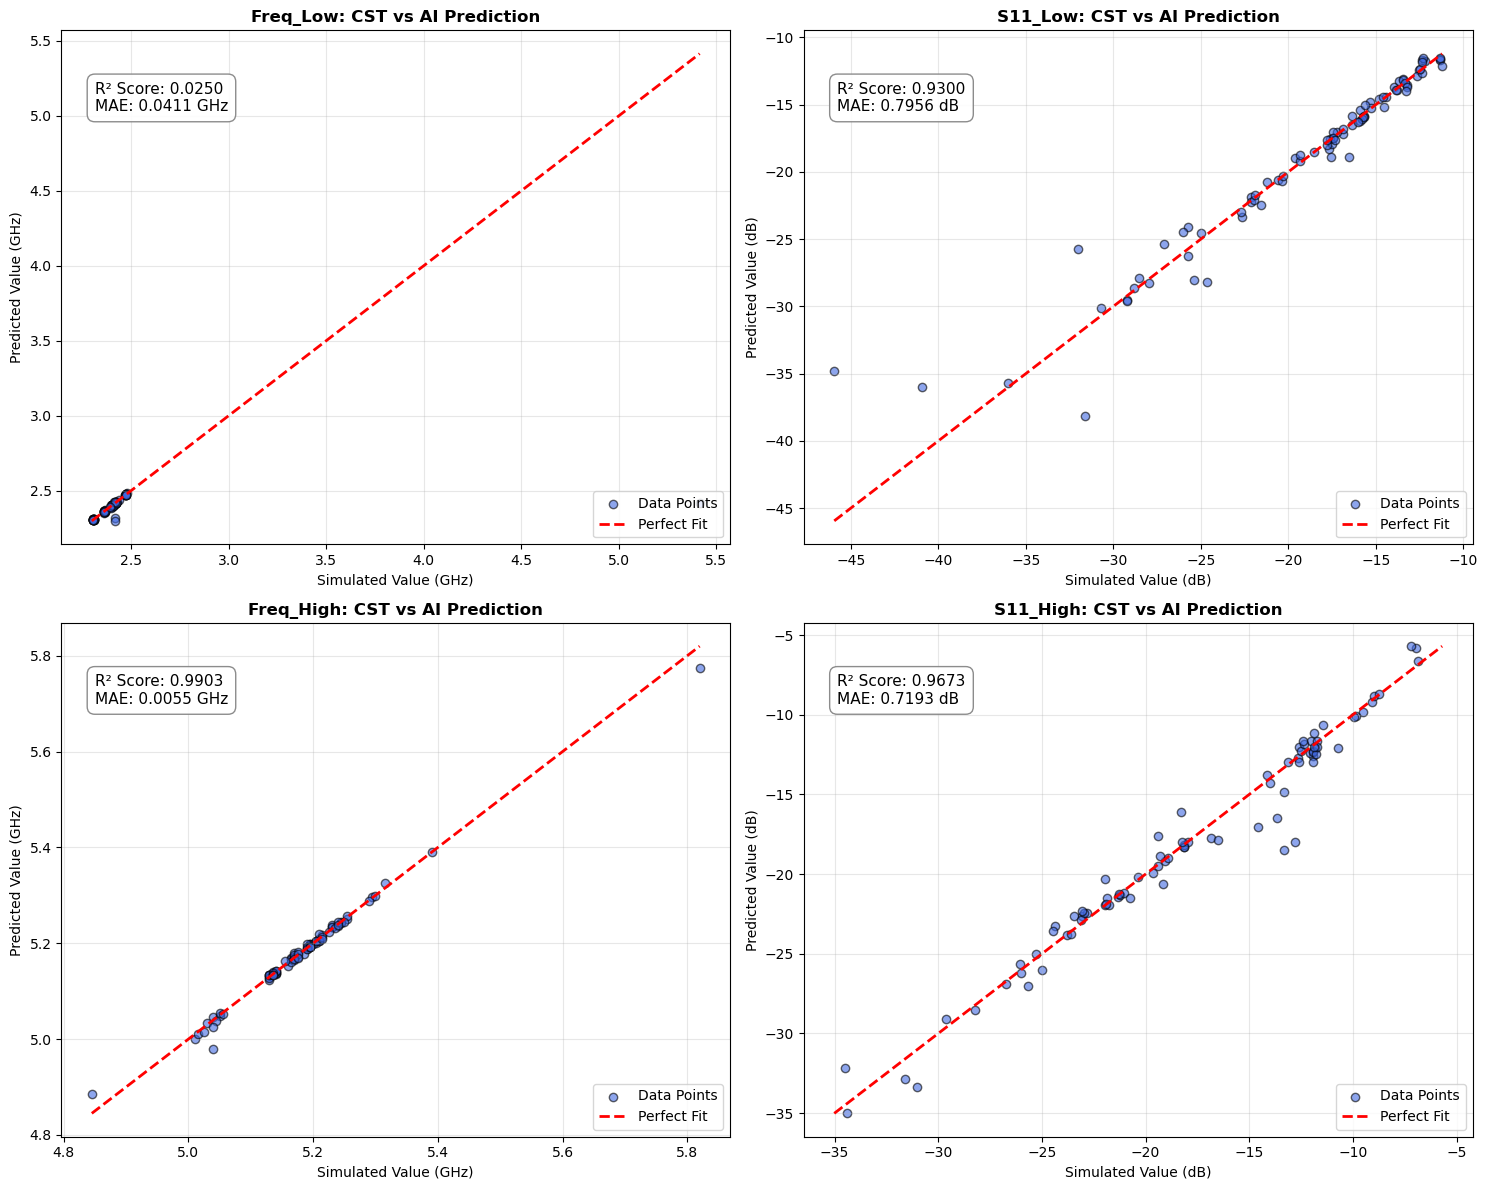

In [34]:
# --- CELL 7: PARITY PLOTS ANN (WITH R2 & MAE) ---

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Select Data
y_real = y_test
y_pred = y_pred_ann  

# 2. Setup Grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# 3. Loop through each output
for i, col in enumerate(output_cols):
    ax = axes[i]
    
    # Get data
    real_vals = y_real.iloc[:, i]
    pred_vals = y_pred[:, i]
    
    # A. Plot Scatter
    ax.scatter(real_vals, pred_vals, color='royalblue', alpha=0.6, edgecolors='k', label='Data Points')
    
    # B. Plot Perfect Fit Line
    min_val = min(real_vals.min(), pred_vals.min())
    max_val = max(real_vals.max(), pred_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    # C. Calculate Metrics
    r2 = r2_score(real_vals, pred_vals)
    mae = mean_absolute_error(real_vals, pred_vals)
    
    # D. Style & Labels
    ax.set_title(f'{col}: CST vs AI Prediction', fontsize=12, fontweight='bold')
    
    # Tentukan unit label (GHz atau dB)
    unit = "GHz" if "Freq" in col else "dB"
    ax.set_xlabel(f'Simulated Value ({unit})', fontsize=10)
    ax.set_ylabel(f'Predicted Value ({unit})', fontsize=10)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # E. Add Text Box with BOTH R2 and MAE
    # Ini bahagian paling penting!
    stats_text = f'R² Score: {r2:.4f}\nMAE: {mae:.4f} {unit}'
    
    ax.text(0.05, 0.9, stats_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'),
            fontsize=11, fontweight='medium', verticalalignment='top')

plt.tight_layout()
plt.show()

c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


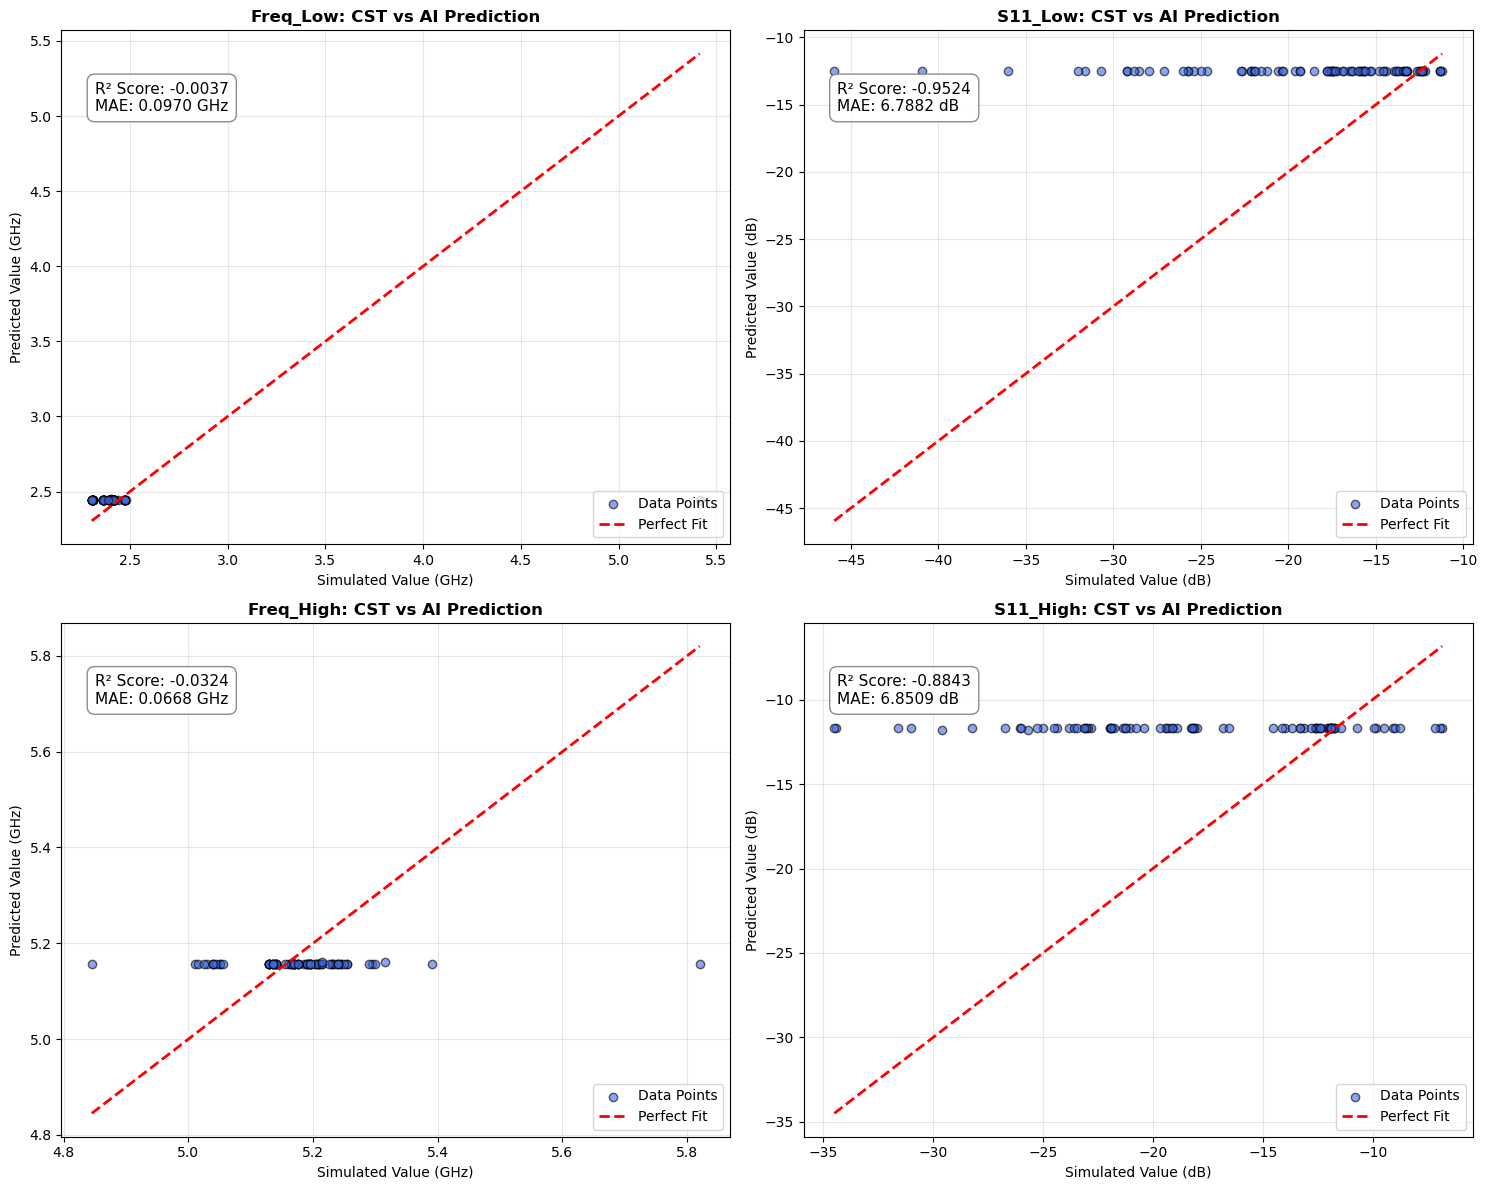

In [35]:
# --- CELL 7.5: PARITY PLOTS RF (WITH R2 & MAE) ---

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Select Data
y_real = y_test
y_pred = rf_model.predict(X_test_scaled)

# 2. Setup Grid
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# 3. Loop through each output
for i, col in enumerate(output_cols):
    ax = axes[i]
    
    # Get data
    real_vals = y_real.iloc[:, i]
    pred_vals = y_pred[:, i]
    
    # A. Plot Scatter
    ax.scatter(real_vals, pred_vals, color='royalblue', alpha=0.6, edgecolors='k', label='Data Points')
    
    # B. Plot Perfect Fit Line
    min_val = min(real_vals.min(), pred_vals.min())
    max_val = max(real_vals.max(), pred_vals.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')
    
    # C. Calculate Metrics
    r2 = r2_score(real_vals, pred_vals)
    mae = mean_absolute_error(real_vals, pred_vals)
    
    # D. Style & Labels
    ax.set_title(f'{col}: CST vs AI Prediction', fontsize=12, fontweight='bold')
    
    # Tentukan unit label (GHz atau dB)
    unit = "GHz" if "Freq" in col else "dB"
    ax.set_xlabel(f'Simulated Value ({unit})', fontsize=10)
    ax.set_ylabel(f'Predicted Value ({unit})', fontsize=10)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

    # E. Add Text Box with BOTH R2 and MAE
    # Ini bahagian paling penting!
    stats_text = f'R² Score: {r2:.4f}\nMAE: {mae:.4f} {unit}'
    
    ax.text(0.05, 0.9, stats_text, transform=ax.transAxes, 
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'),
            fontsize=11, fontweight='medium', verticalalignment='top')

plt.tight_layout()
plt.show()

In [36]:
# ---ANN EXTRA CELL: REVERSE ENGINEERING AI (INVERSE DESIGN) --- TRY TEST----

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import pandas as pd

df = pd.read_excel('Dataset_Antenna.xlsx')
X = df[['Patch_W', 'Patch_L', 'Inset_L', 'Slot_L', 'Slot_W', 'Slot_Pos', 'Slot_Offset_X']]
y = df[['Freq_Low', 'S11_Low', 'Freq_High', 'S11_High']]

print("Training AI for 'Inverse Design' (Please wait)...")

# 1. Swap Data (Output becomes Input, Input becomes Output)
# ask the AI: "If want this Frequency, what dimensions do need?"
X_reverse = y  # Simulation Results (Freq/S11) act as the INPUT (Question)
y_reverse = X  # Dimensions (Patch/Slot) act as the OUTPUT (Answer)

# Split Data for the Reverse Model
X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(X_reverse, y_reverse, test_size=0.2, random_state=42)

# Scale Data (Crucial for Neural Networks)
scaler_X_rev = StandardScaler()
scaler_y_rev = StandardScaler()

X_train_rev_sc = scaler_X_rev.fit_transform(X_train_rev)
y_train_rev_sc = scaler_y_rev.fit_transform(y_train_rev)

# 2. Train the Reverse Model (Reverse ANN)
# We use a slightly larger network since inverse problems are harder
reverse_ann = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=2000, random_state=42)
reverse_ann.fit(X_train_rev_sc, y_train_rev_sc)
print("Reverse AI is Ready!")

print("ANN Inverse Model is Ready!")
print("-" * 60)

# 3. TEST THE AI! (Enter Your Dream Target Results Here)
# Format: [Freq_Low, S11_Low, Freq_High, S11_High]
# Example below: I want exactly 2.45 GHz and 5.20 GHz with good S11.
target_result = [[2.4, -15.88477, 5.2, -23.06848]] 

# Predict the Required Dimensions
target_scaled = scaler_X_rev.transform(target_result)
predicted_dims_scaled = reverse_ann.predict(target_scaled)
predicted_dims = scaler_y_rev.inverse_transform(predicted_dims_scaled)

# 4. Display Results
print(f"YOUR TARGET SPECIFICATIONS:")
print(f"   Freq Low: {target_result[0][0]} GHz, S11: {target_result[0][1]} dB")
print(f"   Freq High: {target_result[0][2]} GHz, S11: {target_result[0][3]} dB")

print("\nAI SUGGESTED DESIGN DIMENSIONS:")
cols = ['Patch_W', 'Patch_L', 'Inset_L', 'Slot_L', 'Slot_W', 'Slot_Pos', 'Slot_Offset_X']
df_res = pd.DataFrame(predicted_dims, columns=cols)
display(df_res)

print("\nNOTE: You can try entering these dimensions into CST Studio to verify if you get the target frequency.")
print("Disclaimer: Inverse design is complex; multiple designs can yield similar frequencies!")

Training AI for 'Inverse Design' (Please wait)...
Reverse AI is Ready!
ANN Inverse Model is Ready!
------------------------------------------------------------
YOUR TARGET SPECIFICATIONS:
   Freq Low: 2.4 GHz, S11: -15.88477 dB
   Freq High: 5.2 GHz, S11: -23.06848 dB

AI SUGGESTED DESIGN DIMENSIONS:


c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Patch_W,Patch_L,Inset_L,Slot_L,Slot_W,Slot_Pos,Slot_Offset_X
0,46.16951,41.287329,10.952637,5.033924,3.318195,10.860323,4.55752



NOTE: You can try entering these dimensions into CST Studio to verify if you get the target frequency.
Disclaimer: Inverse design is complex; multiple designs can yield similar frequencies!


In [37]:
# --- EXTRA CELL: RANDOM FOREST REVERSE ENGINEERING (INVERSE DESIGN) ---

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

print("Training Random Forest for 'Inverse Design' (Please wait)...")

# 1. Swap Data (Output becomes Input, Input becomes Output)
# Input (X) = Simulation Results (Freq/S11)
# Output (y) = Physical Dimensions (Wp, Lp, etc.)
X_reverse = y  
y_reverse = X  

# Split Data (80% Training, 20% Testing)
X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(
    X_reverse, y_reverse, test_size=0.2, random_state=42
)

# 2. Train the Reverse Model (Random Forest)
# Using 300 trees and min_samples_split=5 as per your Chapter 3 settings
reverse_rf = RandomForestRegressor(n_estimators=300, min_samples_split=5, random_state=42)
reverse_rf.fit(X_train_rev, y_train_rev)

print("RF Inverse Model is Ready!")
print("-" * 60)

# 3. TEST THE AI! (Enter Your Target Specifications)
# Format: [[Freq_Low, S11_Low, Freq_High, S11_High]]
# Example: Targeting exactly 2.40 GHz and 5.20 GHz
target_specs = [[2.4, -15.88477, 5.2, -23.06848]] 

# Predict the Required Dimensions directly (No scaling needed for RF)
predicted_dims = reverse_rf.predict(target_specs)

# 4. Display Results
print(f"YOUR TARGET SPECIFICATIONS:")
print(f"   Freq Low: {target_specs[0][0]} GHz, S11: {target_specs[0][1]} dB")
print(f"   Freq High: {target_specs[0][2]} GHz, S11: {target_specs[0][3]} dB")

print("\nRF SUGGESTED DESIGN DIMENSIONS (mm):")
cols = ['Patch_W', 'Patch_L', 'Inset_L', 'Slot_L', 'Slot_W', 'Slot_Pos', 'Slot_Offset_X']
df_res = pd.DataFrame(predicted_dims, columns=cols)
display(df_res)

print("\nNOTE: Enter these dimensions into CST Studio Suite to verify the performance.")

Training Random Forest for 'Inverse Design' (Please wait)...
RF Inverse Model is Ready!
------------------------------------------------------------
YOUR TARGET SPECIFICATIONS:
   Freq Low: 2.4 GHz, S11: -15.88477 dB
   Freq High: 5.2 GHz, S11: -23.06848 dB

RF SUGGESTED DESIGN DIMENSIONS (mm):


c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


,Patch_W,Patch_L,Inset_L,Slot_L,Slot_W,Slot_Pos,Slot_Offset_X
0,46.197829,41.363904,11.0,5.0,3.648363,11.870506,4.003556



NOTE: Enter these dimensions into CST Studio Suite to verify the performance.
